In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [36]:
# 1. Configuracao: altere estes valores para explorar outra regiao ou variavel.
REGION = "BA_SE"
INPUT_FILE = "2t.nc"
PCA_COMPONENTS = 0.99  # 0.95 mantem 95% da variancia; 20 fixa 20 componentes.

input_path = Path("../../data/processed/meteoro-recortado") / REGION / INPUT_FILE
with xr.open_dataset(input_path) as source_dataset:
    variable_name = next(iter(source_dataset.data_vars))
    data = source_dataset[variable_name].load()

print(f"Regiao: {REGION}")
print(f"Variavel: {variable_name}")
print(f"Periodo: {data.time.values[0]} ate {data.time.values[-1]}")
print(f"Dimensoes originais: {dict(data.sizes)}")

Regiao: BA_SE
Variavel: t2m
Periodo: 2023-09-30T01:00:00.000000000 ate 2026-09-01T00:00:00.000000000
Dimensoes originais: {'time': 25608, 'latitude': 32, 'longitude': 33}


In [37]:
# 2. Prepara uma matriz com linhas temporais e colunas espaciais.
spatial_dimensions = tuple(dimension for dimension in data.dims if dimension != "time")
matrix = data.stack(spatial_point=spatial_dimensions).transpose("time", "spatial_point")
matrix = matrix.dropna(dim="spatial_point", how="all")

n_times = matrix.sizes["time"]
train_end = int(n_times * 0.70)
validation_end = int(n_times * 0.85)
train_slice = slice(0, train_end)
validation_slice = slice(train_end, validation_end)
test_slice = slice(validation_end, n_times)

# A PCA e ajustada apenas no treino. Pontos sem nenhuma observacao no treino
# nao podem ser imputados e sao removidos antes do ajuste.
observed_in_train = ~np.isnan(matrix.isel(time=train_slice).values).all(axis=0)
matrix = matrix.isel(spatial_point=np.flatnonzero(observed_in_train))

In [38]:
# 3. Imputa lacunas, padroniza e ajusta a PCA sem usar validacao ou teste.
values = matrix.values
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
train_values = scaler.fit_transform(imputer.fit_transform(values[train_slice]))
validation_values = scaler.transform(imputer.transform(values[validation_slice]))
test_values = scaler.transform(imputer.transform(values[test_slice]))

pca = PCA(n_components=PCA_COMPONENTS)
transformed = np.concatenate(
    (
        pca.fit_transform(train_values),
        pca.transform(validation_values),
        pca.transform(test_values),
    )
)

In [39]:
# 4. Organiza o resultado para consulta com xarray.
component_dimension = f"{variable_name}_pca_component"
split = np.empty(n_times, dtype="U10")
split[train_slice] = "train"
split[validation_slice] = "validation"
split[test_slice] = "test"

pca_features = xr.DataArray(
    transformed,
    dims=("time", component_dimension),
    coords={
        "time": matrix.time.values,
        component_dimension: np.arange(1, transformed.shape[1] + 1),
        "split": ("time", split),
    },
    name=f"{variable_name}_pca",
)
result = xr.Dataset({pca_features.name: pca_features})

print(f"Pontos espaciais usados: {matrix.sizes['spatial_point']}")
print(f"Componentes criados: {transformed.shape[1]}")
print(f"Variancia explicada: {pca.explained_variance_ratio_.sum():.2%}")
display(result)

Pontos espaciais usados: 613
Componentes criados: 22
Variancia explicada: 99.01%


<xarray.Dataset> Size: 3MB
Dimensions:            (time: 25608, t2m_pca_component: 22)
Coordinates:
  * time               (time) datetime64[ns] 205kB 2023-09-30T01:00:00 ... 20...
    split              (time) <U10 1MB 'train' 'train' 'train' ... 'test' 'test'
  * t2m_pca_component  (t2m_pca_component) int64 176B 1 2 3 4 5 ... 19 20 21 22
Data variables:
    t2m_pca            (time, t2m_pca_component) float32 2MB -2.857 ... -0.04274

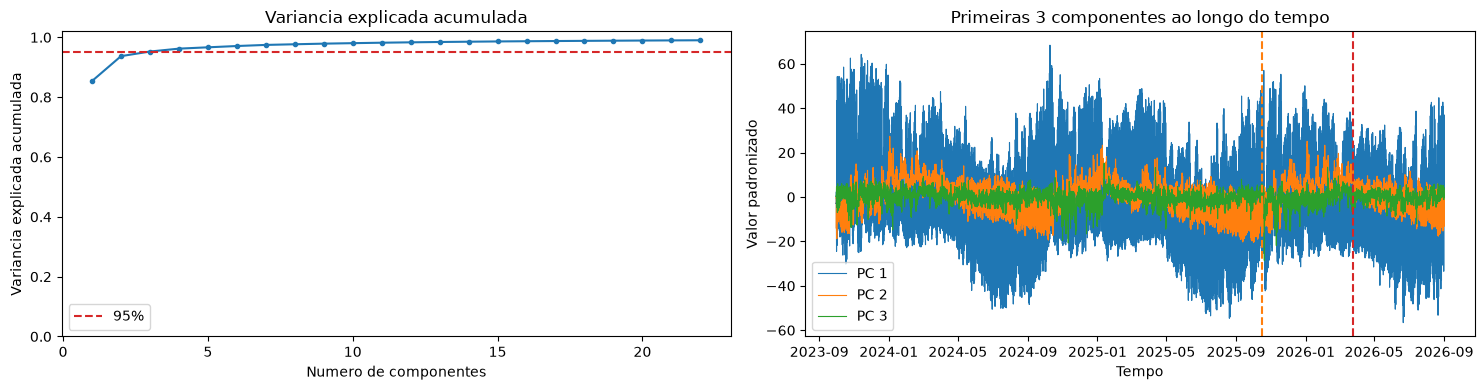

In [40]:
# 5. Analisa quanta variancia cada componente representa e sua serie temporal.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
components = np.arange(1, len(cumulative_variance) + 1)
components_to_plot = min(3, transformed.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(components, cumulative_variance, marker="o", markersize=3)
axes[0].axhline(0.95, color="tab:red", linestyle="--", label="95%")
axes[0].set(
    title="Variancia explicada acumulada",
    xlabel="Numero de componentes",
    ylabel="Variancia explicada acumulada",
    ylim=(0, 1.02),
)
axes[0].legend()

for component in range(components_to_plot):
    axes[1].plot(
        pca_features.time.values,
        pca_features.isel({component_dimension: component}),
        label=f"PC {component + 1}",
        linewidth=0.8,
    )
axes[1].axvline(pca_features.time.values[train_end], color="tab:orange", linestyle="--")
axes[1].axvline(pca_features.time.values[validation_end], color="tab:red", linestyle="--")
axes[1].set(
    title=f"Primeiras {components_to_plot} componentes ao longo do tempo",
    xlabel="Tempo",
    ylabel="Valor padronizado",
)
axes[1].legend()

fig.tight_layout()
plt.show()

In [44]:
ds = xr.open_dataset('../data/BA_SE_pca.nc')
ds['t2m_pca']

<xarray.DataArray 't2m_pca' (time: 25584, t2m_pca_component: 3)> Size: 307kB
[76752 values with dtype=float32]
Coordinates:
  * time               (time) datetime64[ns] 205kB 2023-10-01 ... 2026-08-31T...
    split              (time) <U10 1MB ...
  * t2m_pca_component  (t2m_pca_component) int64 24B 0 1 2
Attributes:
    source_variable:           t2m
    pca_components_requested:  0.95
    explained_variance_ratio:  [0.85381985 0.08323883 0.01542829]